Лабораторная работа 6

Выполнила студентка группы 6131-010402D Фролова Анастасия Сергеевна

1:

Считать в pandas.DataFrame любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.


In [2]:
import numpy as np
import pandas as pd

from pathlib import Path
from matplotlib import pyplot as plt

import sklearn as sk
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [3]:
path = '...'

df = pd.read_csv(Path(path, 'loan_data.csv'))

2:

Датасет и подготовка данных:


Привести описание датасета.


Датасет содержит записи о персональных и финансовых данных. Эти данные используются для понимания факторов финансового риска и моделирования процессов прогнозного моделирования для одобрения кредитов и кредитного скоринга.
* person_age - возраст;
* person_gender - пол;
* person_education - наивысший уровень образования;
* person_income - годовой доход;
* person_emp_exp - количество лет трудового стажа;
* person_home_ownership - статус владения жильем (аренда, собственное, ипотека);
* loan_amnt - запрашиваемая сумма кредита;
* loan_intent — цель кредита;
* loan_int_rate — процентная ставка по кредиту;
* loan_percent_income — сумма кредита в процентах от годового дохода;
* cb_person_cred_hist_length — продолжительность кредитной истории в годах;
* credit_score — кредитный рейтинг человека;
* previous_loan_defaults_on_file — индикатор предыдущих невыплат кредита;
* loan_status — статус одобрения кредита (1 = одобрено; 0 = отклонено).

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Осуществить предобработку данных (избавиться от null, убрать некоторые признаки и т.п.) - "подчистить данные".


In [5]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [6]:
cat_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file'] # Столбцы с категориальными признаками

num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status'] # Столбцы с численными

Нормализовать численные данные.


In [7]:
# Выполним нормализацию

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

Разбить выборку на обучающую и тестовую.


In [8]:
# Категориальные признаки, как есть

X_as_is = df.drop('loan_status', axis=1)
y_as_is = df['loan_status']

X_train_as_is, X_test_as_is, y_train_as_is, y_test_as_is = train_test_split(X_as_is,y_as_is, test_size= 0.3, random_state= 42)

In [10]:
# Кодируем категориальные

df_drop = pd.get_dummies(df, columns=cat_cols, drop_first=False) #OneHot Encoder
df_drop.info() # Проверяем, что кодирование прошло успешно

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_age                          45000 non-null  float64
 1   person_income                       45000 non-null  float64
 2   person_emp_exp                      45000 non-null  float64
 3   loan_amnt                           45000 non-null  float64
 4   loan_int_rate                       45000 non-null  float64
 5   loan_percent_income                 45000 non-null  float64
 6   cb_person_cred_hist_length          45000 non-null  float64
 7   credit_score                        45000 non-null  float64
 8   loan_status                         45000 non-null  float64
 9   person_gender_female                45000 non-null  bool   
 10  person_gender_male                  45000 non-null  bool   
 11  person_education_Associate          45000

In [11]:
X = df_drop.drop('loan_status', axis=1)
y = df_drop['loan_status']

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X,y, test_size= 0.3, random_state= 42)

3:

Для каждого из классификаторов (AdaBoostClassifier, GradientBoostingClassifier, XGBClassifier, CatBoostClassifier)

С использованием GridSearchCV/grid_search осуществить подбор гиперпараметра модели, использовать выборки с закодированными категориальными признаками.

In [12]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.6 MB/s eta 0:00:00


In [13]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [14]:
import catboost
from catboost import CatBoostClassifier

In [15]:
from sklearn.metrics import classification_report

In [16]:
# AdaBoost

ADA = AdaBoostClassifier(n_estimators= 50, learning_rate= 1.0, algorithm="SAMME", random_state= 42)
ADA.fit(X_train_cat, y_train_cat)
y_predict = ADA.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict))

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94     10493
         1.0       0.78      0.80      0.79      3007

    accuracy                           0.90     13500
   macro avg       0.86      0.87      0.86     13500
weighted avg       0.91      0.90      0.91     13500



In [ ]:
# Модель хорошо предсказывает класс 0 и также 1, хоть и несколько хуже, однако все же стоит подобрать гиперпараметры для лучшей модели

In [17]:
ada_grid = {
    'n_estimators': range(10, 50, 10),  # количество деревьев в ансамбле
    'learning_rate': np.arange(0.01, 1, 0.1),  # скорость обучения
}

ada_grid_search = GridSearchCV(ADA, ada_grid, cv = 5, verbose= 2, n_jobs= -1)
ada_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(algorithm='SAMME', random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': array([0.01, 0.11, 0.21, 0.31, 0.41, 0.51, 0.61, 0.71, 0.81, 0.91]),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [18]:
ada_grid_search.best_params_

{'learning_rate': np.float64(0.91), 'n_estimators': 40}

In [20]:
y_predict_ada = ada_grid_search.predict(X_test_cat)

print("Before grid search:")
print(classification_report(y_test_cat, y_predict))

print("After grid search:")
print(classification_report(y_test_cat, y_predict_ada))

Before grid search:
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94     10493
         1.0       0.78      0.80      0.79      3007

    accuracy                           0.90     13500
   macro avg       0.86      0.87      0.86     13500
weighted avg       0.91      0.90      0.91     13500

After grid search:
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94     10493
         1.0       0.79      0.78      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.87      0.86      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# После подбора гиперпараметров результат почти не изменился, лишь общая точность выросла на 0.01
# Далее будем осуществлять подбор гиперпараметров для остальных моделей

In [22]:
# GradientBoostingClassifier

grad_grid = {
    'n_estimators': range(10, 50, 10),
    'learning_rate': np.arange(0.01, 0.1, 0.1),
    'max_depth': range(1, 6),
}

grad_model = GradientBoostingClassifier()

grad_grid_search = GridSearchCV(grad_model, grad_grid, cv = 5, verbose= 2, n_jobs= -1)

grad_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': array([0.01]),
                         'max_depth': range(1, 6),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [23]:
grad_grid_search.best_params_

{'learning_rate': np.float64(0.01), 'max_depth': 1, 'n_estimators': 10}

In [24]:
y_predict_grad = grad_grid_search.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_grad, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [ ]:
# Данный классификатор неплохо предсказывает класс 0, однако класс 1 определяется плохо

In [25]:
# XGBoost

# Для начала подберем основные параметры модели

xgb_model = XGBClassifier()

xgb_grid_search = GridSearchCV(xgb_model, grad_grid, cv = 5, verbose= 2, n_jobs= -1)

xgb_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': array([0.01]),
                         'max_depth': range(1, 6),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [26]:
xgb_grid_search.best_params_

{'learning_rate': np.float64(0.01), 'max_depth': 1, 'n_estimators': 10}

In [27]:
y_predict_xgb_bef = xgb_grid_search.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_xgb_bef, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [28]:
# Подбираем дополнительные параметры, может улучшить результат

xgb_model_params = {
    'n_estimators': [10],
    'learning_rate': [0.01],
    'max_depth': [1],
    'gamma': np.arange(0, 1.5, 0.5),
    'lambda': np.arange(0, 2.5, 0.5),
    'alpha': np.arange(0, 1.5, 0.5),
}

xgb_model = XGBClassifier()

xgb_grid_search = GridSearchCV(xgb_model, xgb_model_params, cv = 5, verbose= 2, n_jobs= -1)

xgb_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'alpha': array([0. , 0.5, 1. ]),
                         'gamma': array([0. , 0.5, 1. ]),
                         'lambda': array([0. , 0.5, 1. , 1.5, 2. ]),
                         'learning_rate': [0.01], 'max_depth': [1],
                         'n_estimators': [10]},
             verbose=2)

In [29]:
xgb_grid_search.best_params_

{'alpha': np.float64(0.0),
 'gamma': np.float64(0.0),
 'lambda': np.float64(0.0),
 'learning_rate': 0.01,
 'max_depth': 1,
 'n_estimators': 10}

In [30]:
y_predict_xgb_af = xgb_grid_search.predict(X_test_cat)

print("Before params search:")
print(classification_report(y_test_cat, y_predict_xgb_bef, zero_division = 0))

print("After params search:")
print(classification_report(y_test_cat, y_predict_xgb_af, zero_division = 0))

Before params search:
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500

After params search:
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [ ]:
# Подбор дополнительных параметров не улучшил результат
# Данный классификатор также неплохо предсказывает класс 0, но с классом 1 все также проблемы

In [31]:
# CatBoost

cat_model = CatBoostClassifier()

cat_grid_search = GridSearchCV(cat_model, grad_grid, cv = 5, verbose= 2, n_jobs= -1)

cat_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
0:	learn: 0.6688365	total: 56.9ms	remaining: 2.22s
1:	learn: 0.6473838	total: 65.4ms	remaining: 1.24s
2:	learn: 0.6254374	total: 73.9ms	remaining: 911ms
3:	learn: 0.6056049	total: 85.1ms	remaining: 766ms
4:	learn: 0.5853510	total: 95.1ms	remaining: 665ms
5:	learn: 0.5673854	total: 105ms	remaining: 597ms
6:	learn: 0.5492645	total: 114ms	remaining: 538ms
7:	learn: 0.5321010	total: 124ms	remaining: 496ms
8:	learn: 0.5171997	total: 137ms	remaining: 473ms
9:	learn: 0.5018526	total: 146ms	remaining: 437ms
10:	learn: 0.4872332	total: 154ms	remaining: 406ms
11:	learn: 0.4745054	total: 165ms	remaining: 385ms
12:	learn: 0.4618285	total: 173ms	remaining: 360ms
13:	learn: 0.4488637	total: 182ms	remaining: 337ms
14:	learn: 0.4373845	total: 190ms	remaining: 317ms
15:	learn: 0.4263671	total: 198ms	remaining: 298ms
16:	learn: 0.4153852	total: 209ms	remaining: 282ms
17:	learn: 0.4063648	total: 218ms	remaining: 266ms
18:	learn: 0.3971131	tota

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostClassifier object at 0x7ba414d02d50>,
             n_jobs=-1,
             param_grid={'learning_rate': array([0.01]),
                         'max_depth': range(1, 6),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [32]:
cat_grid_search.best_params_

{'learning_rate': np.float64(0.01), 'max_depth': 5, 'n_estimators': 40}

In [33]:
cat_model_after = CatBoostClassifier(n_estimators=40, max_depth=5, learning_rate=0.01)
cat_model_after.fit(X_train_cat, y_train_cat)

0:	learn: 0.6688365	total: 9.96ms	remaining: 389ms
1:	learn: 0.6473838	total: 18.8ms	remaining: 357ms
2:	learn: 0.6254374	total: 27.6ms	remaining: 340ms
3:	learn: 0.6056049	total: 36ms	remaining: 324ms
4:	learn: 0.5853510	total: 45ms	remaining: 315ms
5:	learn: 0.5673854	total: 54.8ms	remaining: 311ms
6:	learn: 0.5492645	total: 67.1ms	remaining: 316ms
7:	learn: 0.5321010	total: 76.9ms	remaining: 308ms
8:	learn: 0.5171997	total: 88.2ms	remaining: 304ms
9:	learn: 0.5018526	total: 96.8ms	remaining: 290ms
10:	learn: 0.4872332	total: 105ms	remaining: 278ms
11:	learn: 0.4745054	total: 115ms	remaining: 268ms
12:	learn: 0.4618285	total: 124ms	remaining: 257ms
13:	learn: 0.4488637	total: 132ms	remaining: 245ms
14:	learn: 0.4373845	total: 141ms	remaining: 235ms
15:	learn: 0.4263671	total: 150ms	remaining: 224ms
16:	learn: 0.4153852	total: 159ms	remaining: 215ms
17:	learn: 0.4063648	total: 169ms	remaining: 207ms
18:	learn: 0.3971131	total: 180ms	remaining: 199ms
19:	learn: 0.3884280	total: 191ms	r

In [34]:
y_predict_cat = cat_model_after.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94     10493
         1.0       0.85      0.73      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.89      0.85      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# Результат для класса 0 хороший, однако для класса 1 он несколько хуже

Обучить модели XGBClassifier и CatBoostClassifier
 с найденными гиперпараметрами на обучающей выборке с категориальными признаками "как есть".

In [35]:
import copy
from copy import deepcopy

In [36]:
from catboost import Pool

In [39]:
cat_cols = [var for var in X_train_as_is.columns if X_train_as_is[var].dtype == 'object']

X_cat_train_1 = deepcopy(X_train_as_is)
X_cat_test_1 = deepcopy(X_test_as_is)


for col in cat_cols:
    X_cat_train_1[col] = pd.Categorical(X_cat_train_1[col])
    X_cat_test_1[col] = pd.Categorical(X_cat_test_1[col])

train_data_cat = Pool(data=X_cat_train_1, label=y_train_cat, cat_features=cat_cols)
test_data_cat  = Pool(data=X_cat_test_1, label=y_test_cat, cat_features=cat_cols)

In [40]:
xgb_model_best = XGBClassifier(n_estimators=10, max_depth=1, learning_rate=0.01, alpha=0.0, gamma=0.0, reg_lambda = 0, objective='binary:logistic', enable_categorical=True, max_cat_to_onehot=10000)
xgb_model_best.fit(X_cat_train_1, y_train_cat)
y_ce_pred_xgb = xgb_model_best.predict(X_cat_test_1)
print(classification_report(y_test_cat, y_ce_pred_xgb, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [42]:
cat_model_best = CatBoostClassifier(n_estimators=40, max_depth=5, learning_rate=0.01)
cat_model_best.fit(train_data_cat)
y_ce_pred_cat = cat_model_best.predict(X_cat_test_1)
print("Results:")
print(classification_report(y_test_cat, y_ce_pred_cat))

0:	learn: 0.6861750	total: 114ms	remaining: 4.44s
1:	learn: 0.6796066	total: 204ms	remaining: 3.87s
2:	learn: 0.6729929	total: 291ms	remaining: 3.59s
3:	learn: 0.6665349	total: 377ms	remaining: 3.39s
4:	learn: 0.6601537	total: 464ms	remaining: 3.25s
5:	learn: 0.6540066	total: 535ms	remaining: 3.03s
6:	learn: 0.6480538	total: 590ms	remaining: 2.78s
7:	learn: 0.6421419	total: 629ms	remaining: 2.52s
8:	learn: 0.6363208	total: 656ms	remaining: 2.26s
9:	learn: 0.6305454	total: 747ms	remaining: 2.24s
10:	learn: 0.6249829	total: 797ms	remaining: 2.1s
11:	learn: 0.6194979	total: 816ms	remaining: 1.9s
12:	learn: 0.6139953	total: 851ms	remaining: 1.77s
13:	learn: 0.6086754	total: 880ms	remaining: 1.63s
14:	learn: 0.6033926	total: 934ms	remaining: 1.55s
15:	learn: 0.5981977	total: 973ms	remaining: 1.46s
16:	learn: 0.5931688	total: 1.01s	remaining: 1.37s
17:	learn: 0.5881837	total: 1.04s	remaining: 1.27s
18:	learn: 0.5834001	total: 1.07s	remaining: 1.18s
19:	learn: 0.5788087	total: 1.09s	remaining

Итого получить 6 обученных моделей.


Вывести метрики на тестовом наборе (как минимум classification_report, другие по желанию).


In [43]:
print("AdaBoostClassifier")
print(classification_report(y_test_cat, y_predict_ada))
print("GradientBoostingClassifier")
print(classification_report(y_test_cat, y_predict_grad, zero_division = 0))
print("XGBClassifier with coded")
print(classification_report(y_test_cat, y_predict_xgb_af, zero_division = 0))
print("CatBoostClassifier with coded")
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))
print("XGBClassifier with default")
print(classification_report(y_test_cat, y_ce_pred_xgb, zero_division = 0))
print("CatBoostClassifier with default")
print(classification_report(y_test_cat, y_ce_pred_cat))

AdaBoostClassifier
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94     10493
         1.0       0.79      0.78      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.87      0.86      0.86     13500
weighted avg       0.91      0.91      0.91     13500

GradientBoostingClassifier
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500

XGBClassifier with coded
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
wei

Сравнить модели, выбрать лучшую.


In [ ]:
# Вывод: Лучший результат показали модели ADABoost и CatBoost с accuracy в 0.91, однако лучшим по метрике precision оказался CatBoost
# Выберем в качестве лучшей модели CatBoostClassifier with coded

4:

Важность признаков:


In [44]:
import shap

С использованием shap.TreeExplainer получить SHAP
-значения для лучшей модели.

In [45]:
tree_explainer = shap.TreeExplainer(cat_model_after)
shap_values = tree_explainer.shap_values(X_train_cat)

Построить график shap.plots.force для одного объекта выборки и для среза произвольного размера.


In [46]:
shap.initjs()
shap_fp = shap.plots.force(tree_explainer.expected_value, shap_values[0,:], X_train_cat.iloc[0,:])

from IPython.display import HTML
HTML(f"<div style='background-color: Lavender;'>{shap.getjs() + shap_fp.html()}</div>")

In [47]:
shap.initjs()
shap_fp = shap.plots.force(tree_explainer.expected_value, shap_values[0:100,:], X_train_cat.iloc[0:100,:])

from IPython.display import HTML
HTML(f"<div style='background-color: Lavender;'>{shap.getjs() + shap_fp.html()}</div>")

Построить график shap.plots.bar для одного объекта выборки.


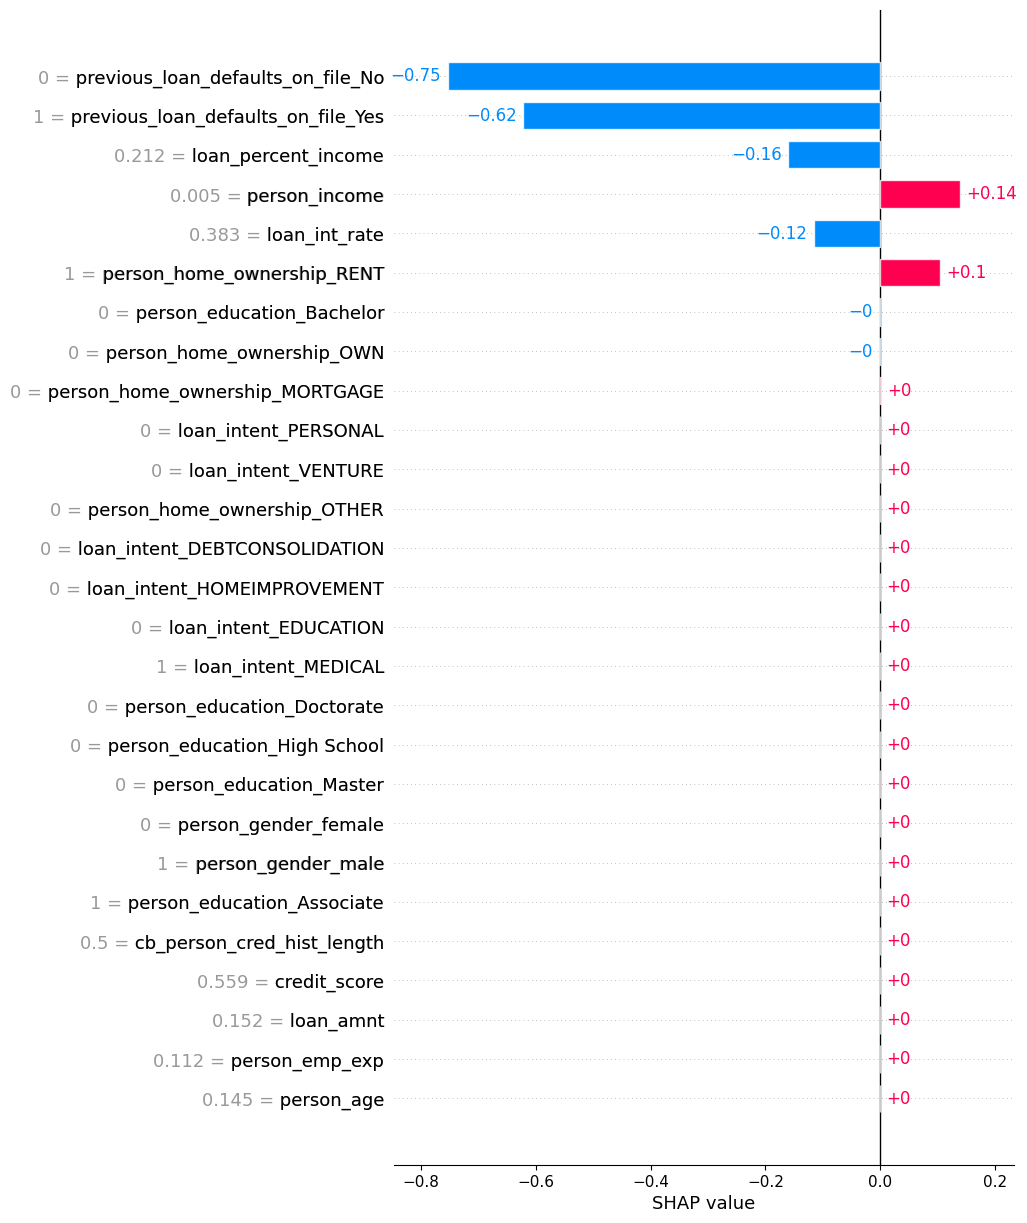

In [48]:
te_df_shap_values  = tree_explainer(X_train_cat)
shap_bp = shap.plots.bar(te_df_shap_values[0], max_display=X_train_cat.shape[1])

Построить график shap.plots.waterfall для одного объекта выборки.


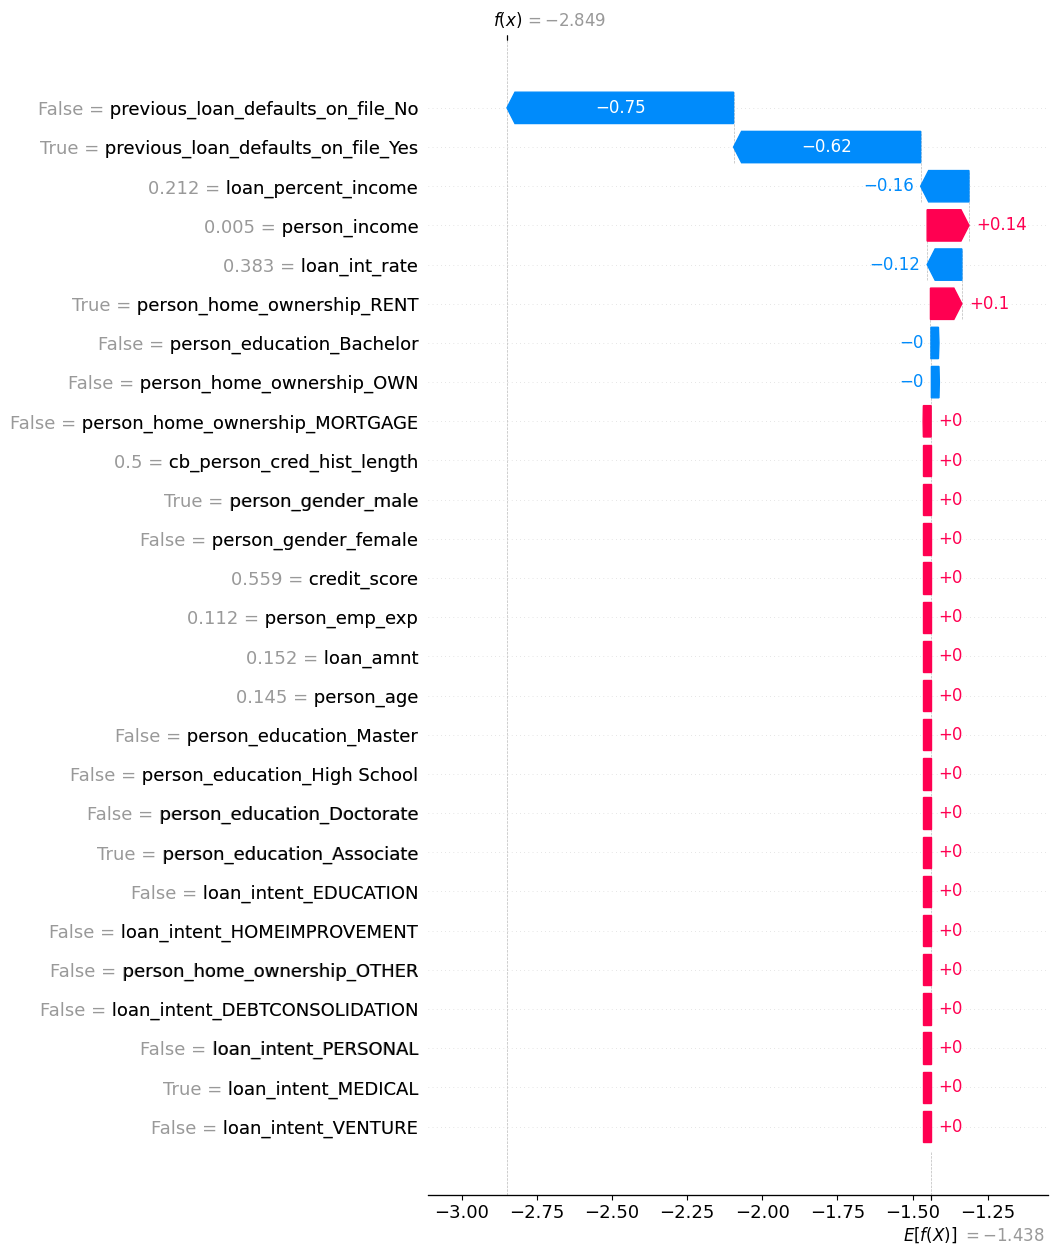

In [49]:
shap.plots.waterfall(te_df_shap_values[0], max_display=X_train_cat.shape[1])

Построить 2 графика shap.plots.scatter для какого-нибудь признака. На одном раскрасить относительно себя, на втором – относительно другого признака.


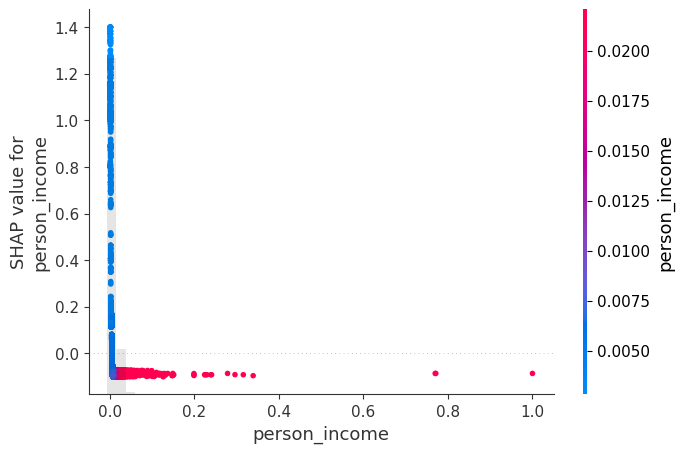

In [50]:
shap.plots.scatter(te_df_shap_values[:, "person_income"], color=te_df_shap_values[:, "person_income"])

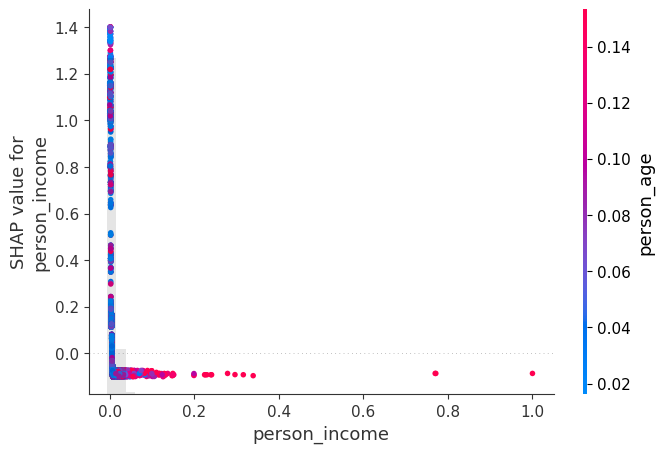

In [51]:
shap.plots.scatter(te_df_shap_values[:, "person_income"], color=te_df_shap_values[:, "person_age"])

Построить график shap.plots.beeswarm для всех признаков.


<Axes: xlabel='SHAP value (impact on model output)'>

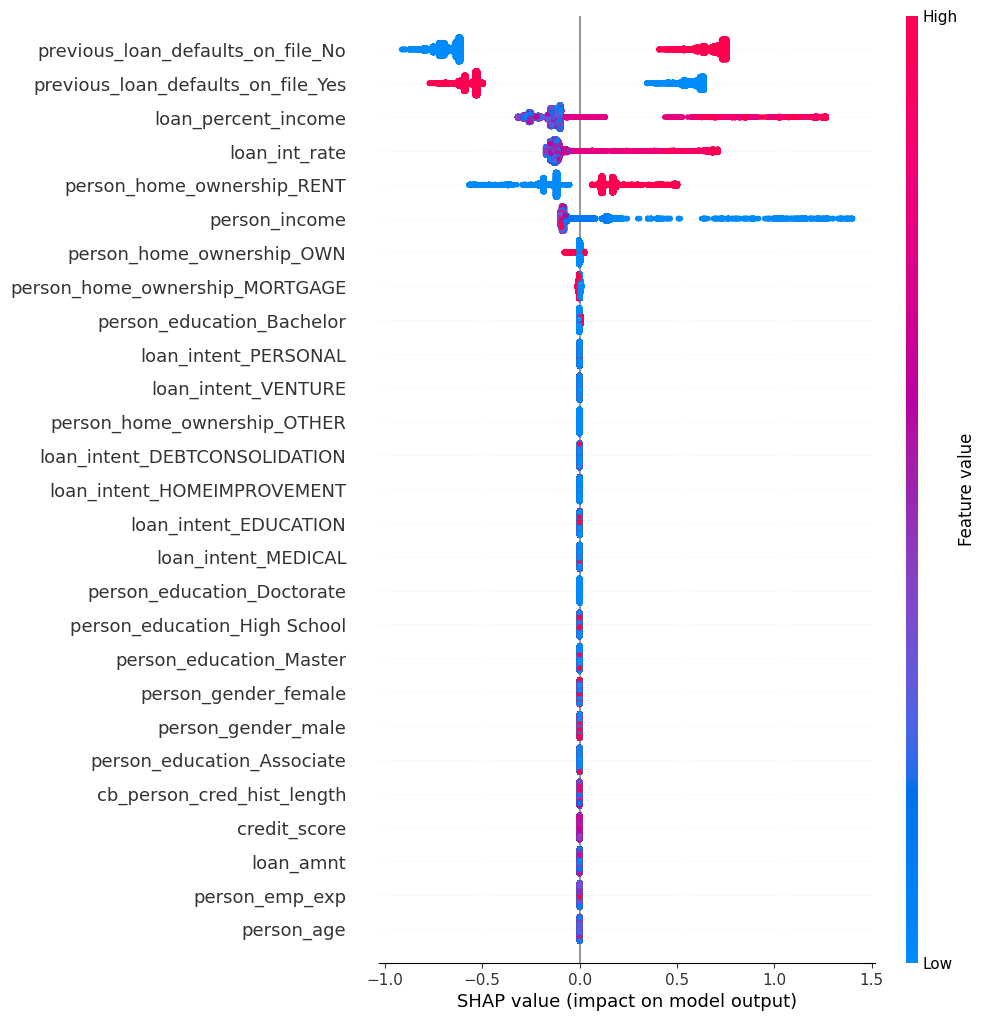

In [52]:
shap.plots.beeswarm(te_df_shap_values, max_display=X_train_cat.shape[1], show=False)

Построить график shap.plots.bar для всех признаков.


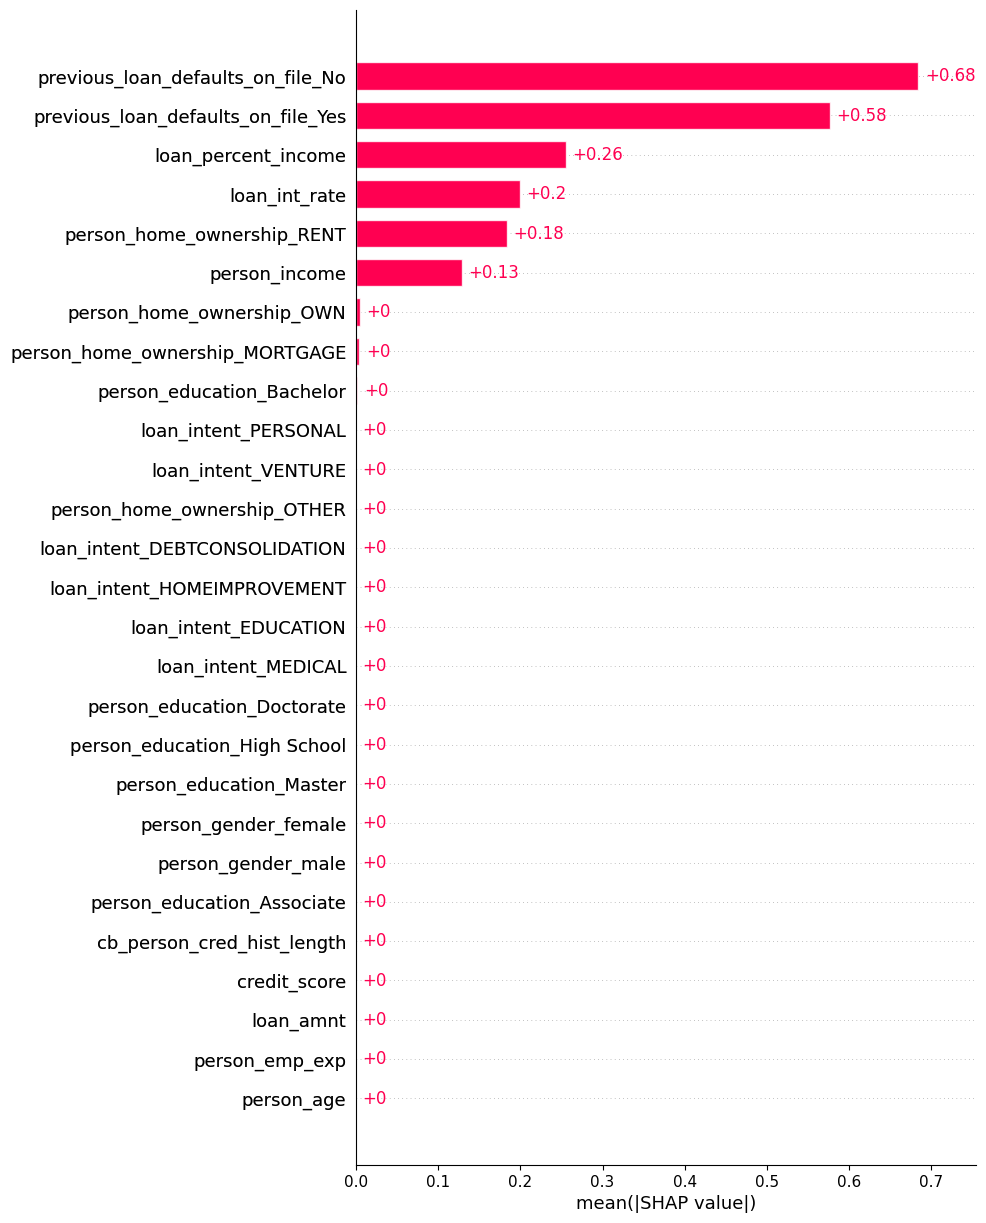

In [53]:
shap.plots.bar(te_df_shap_values, max_display=X_train_cat.shape[1])

На основании двух последних графиков и/или используя feature_importance отфильровать признаки (отразить сформулированные выводы в тексте), переобучить лучшую модель.


In [ ]:
# Оставим признаки с важностью больше 0

In [54]:
filter_cols = ['previous_loan_defaults_on_file_No', 'previous_loan_defaults_on_file_Yes','loan_percent_income', 'loan_int_rate', "person_home_ownership_RENT", "person_income"]

In [55]:
cat_model_after.fit(X_train_cat[filter_cols], y_train_cat)

0:	learn: 0.6862335	total: 23.8ms	remaining: 927ms
1:	learn: 0.6795069	total: 46.9ms	remaining: 892ms
2:	learn: 0.6728344	total: 62.5ms	remaining: 771ms
3:	learn: 0.6663626	total: 83.2ms	remaining: 748ms
4:	learn: 0.6597458	total: 106ms	remaining: 741ms
5:	learn: 0.6535340	total: 126ms	remaining: 716ms
6:	learn: 0.6475009	total: 143ms	remaining: 675ms
7:	learn: 0.6412606	total: 154ms	remaining: 616ms
8:	learn: 0.6352870	total: 165ms	remaining: 569ms
9:	learn: 0.6293169	total: 178ms	remaining: 535ms
10:	learn: 0.6234336	total: 191ms	remaining: 504ms
11:	learn: 0.6177562	total: 208ms	remaining: 486ms
12:	learn: 0.6121898	total: 227ms	remaining: 472ms
13:	learn: 0.6067035	total: 245ms	remaining: 454ms
14:	learn: 0.6013377	total: 265ms	remaining: 442ms
15:	learn: 0.5959488	total: 283ms	remaining: 424ms
16:	learn: 0.5907386	total: 292ms	remaining: 395ms
17:	learn: 0.5854830	total: 306ms	remaining: 374ms
18:	learn: 0.5805392	total: 323ms	remaining: 357ms
19:	learn: 0.5754059	total: 337ms	rem

Сравнить метрики до и после фильтрации.


In [56]:
y_predict_filter = cat_model_after.predict(X_test_cat[filter_cols])
print("Before:")
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))
print("After:")
print(classification_report(y_test_cat, y_predict_filter, zero_division = 0))

Before:
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94     10493
         1.0       0.85      0.73      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.89      0.85      0.86     13500
weighted avg       0.91      0.91      0.91     13500

After:
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94     10493
         1.0       0.84      0.74      0.78      3007

    accuracy                           0.91     13500
   macro avg       0.88      0.85      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# Метрики почти не изменились, разница в сотых в некоторых параметрах, однако количество признаков было уменьшено до 6

Визуализировать полученное дерево решений.


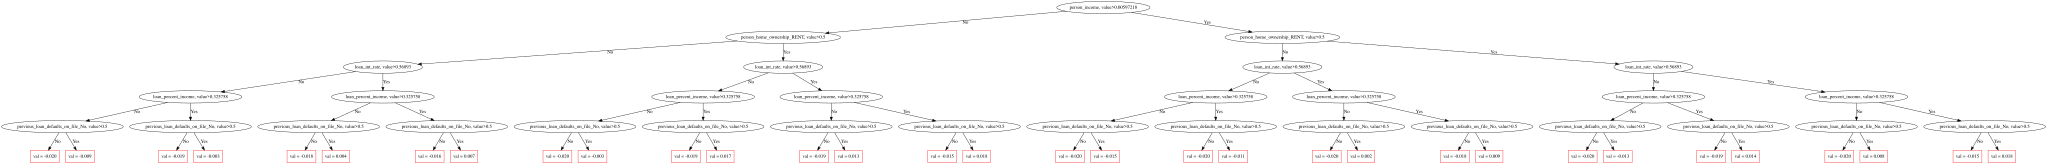

In [57]:
cat_model_after.plot_tree(
    tree_idx=0,
    pool=Pool(data=X_train_cat[filter_cols], label=y_train_cat)
)


5:

Регрессия:


С использованием GridSearchCV/grid_search осуществить подбор гиперпараметра модели линейной регрессии с использованием XGBoost или CatBoost

In [58]:
from catboost import CatBoostRegressor

In [59]:
model = CatBoostRegressor(random_state=42)

CatBoost_param = {
    'iterations': [50, 100],
    'learning_rate': np.arange(0.05, 1.05, 0.05),
    'depth': np.arange(1, 5, 1),
}

model_CatBoostRegressor_grid = GridSearchCV(model, CatBoost_param, cv=5, verbose= 2, n_jobs= -1)
model_CatBoostRegressor_grid.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
0:	learn: 0.3082027	total: 5.51ms	remaining: 546ms
1:	learn: 0.2749059	total: 10.1ms	remaining: 494ms
2:	learn: 0.2627789	total: 14.6ms	remaining: 470ms
3:	learn: 0.2572737	total: 18.8ms	remaining: 451ms
4:	learn: 0.2530509	total: 23.7ms	remaining: 450ms
5:	learn: 0.2502087	total: 28.1ms	remaining: 441ms
6:	learn: 0.2486557	total: 32.5ms	remaining: 432ms
7:	learn: 0.2466189	total: 36.8ms	remaining: 423ms
8:	learn: 0.2456678	total: 41.3ms	remaining: 418ms
9:	learn: 0.2443047	total: 45.5ms	remaining: 410ms
10:	learn: 0.2438153	total: 49.9ms	remaining: 404ms
11:	learn: 0.2430080	total: 54.2ms	remaining: 398ms
12:	learn: 0.2425532	total: 58.7ms	remaining: 393ms
13:	learn: 0.2422322	total: 63.4ms	remaining: 390ms
14:	learn: 0.2415673	total: 67.8ms	remaining: 384ms
15:	learn: 0.2412297	total: 72.1ms	remaining: 379ms
16:	learn: 0.2408703	total: 76.4ms	remaining: 373ms
17:	learn: 0.2407029	total: 80.7ms	remaining: 368ms
18:	learn: 

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostRegressor object at 0x7ba3f1e0f890>,
             n_jobs=-1,
             param_grid={'depth': array([1, 2, 3, 4]), 'iterations': [50, 100],
                         'learning_rate': array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])},
             verbose=2)

In [60]:
model_CatBoostRegressor_grid.best_params_

{'depth': np.int64(4), 'iterations': 100, 'learning_rate': np.float64(0.55)}

In [61]:
best_reg = CatBoostRegressor(depth=4, learning_rate=0.45, iterations=100, random_state=42)

In [62]:
best_reg.fit(X_train_cat, y_train_cat)

0:	learn: 0.3236487	total: 7.44ms	remaining: 736ms
1:	learn: 0.2857412	total: 12.8ms	remaining: 628ms
2:	learn: 0.2701913	total: 17.3ms	remaining: 558ms
3:	learn: 0.2611445	total: 21.5ms	remaining: 517ms
4:	learn: 0.2568693	total: 26.2ms	remaining: 497ms
5:	learn: 0.2529830	total: 31.1ms	remaining: 487ms
6:	learn: 0.2507397	total: 35.6ms	remaining: 473ms
7:	learn: 0.2490858	total: 39.9ms	remaining: 459ms
8:	learn: 0.2474826	total: 44ms	remaining: 445ms
9:	learn: 0.2457648	total: 48.3ms	remaining: 434ms
10:	learn: 0.2452813	total: 52.5ms	remaining: 425ms
11:	learn: 0.2447008	total: 56.7ms	remaining: 416ms
12:	learn: 0.2440770	total: 61.1ms	remaining: 409ms
13:	learn: 0.2435621	total: 65.2ms	remaining: 400ms
14:	learn: 0.2433212	total: 69.5ms	remaining: 394ms
15:	learn: 0.2425325	total: 74ms	remaining: 388ms
16:	learn: 0.2423621	total: 78.1ms	remaining: 381ms
17:	learn: 0.2418810	total: 82.6ms	remaining: 376ms
18:	learn: 0.2416280	total: 86.9ms	remaining: 370ms
19:	learn: 0.2411329	total

In [63]:
y_pred_reg = best_reg.predict(X_test_cat)

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Вывести метрики MSE, MAE и R2
 на тестовом наборе.

In [65]:
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg):.2f}")

Средняя квадратичная ошибка (MSE): 0.05
Средняя абсолютная ошибка (MAE): 0.13
Коэффициент детерминации (R2): 0.69


Переобучить модель на отфильтрованном наборе признаков из пункта 4.


In [66]:
best_reg.fit(X_train_cat[filter_cols], y_train_cat)

0:	learn: 0.3311868	total: 4.79ms	remaining: 474ms
1:	learn: 0.2855744	total: 8.25ms	remaining: 404ms
2:	learn: 0.2702452	total: 11.7ms	remaining: 379ms
3:	learn: 0.2633912	total: 16.5ms	remaining: 397ms
4:	learn: 0.2581693	total: 20.1ms	remaining: 382ms
5:	learn: 0.2562613	total: 23.4ms	remaining: 367ms
6:	learn: 0.2550082	total: 26.9ms	remaining: 357ms
7:	learn: 0.2541949	total: 32.6ms	remaining: 375ms
8:	learn: 0.2534740	total: 38.1ms	remaining: 385ms
9:	learn: 0.2531450	total: 41.5ms	remaining: 373ms
10:	learn: 0.2528437	total: 45ms	remaining: 364ms
11:	learn: 0.2523144	total: 48.5ms	remaining: 356ms
12:	learn: 0.2519320	total: 51.9ms	remaining: 348ms
13:	learn: 0.2517582	total: 56.1ms	remaining: 344ms
14:	learn: 0.2514658	total: 59.6ms	remaining: 338ms
15:	learn: 0.2513067	total: 62.9ms	remaining: 330ms
16:	learn: 0.2508378	total: 66.3ms	remaining: 324ms
17:	learn: 0.2505592	total: 69.9ms	remaining: 319ms
18:	learn: 0.2499594	total: 74.5ms	remaining: 318ms
19:	learn: 0.2498682	tot

In [67]:
y_pred_reg_fil = best_reg.predict(X_test_cat)

Сравнить метрики до и после фильтрации.


In [68]:
print("Before:")
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg):.2f}")

print("After:")
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg_fil):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg_fil):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg_fil):.2f}")

Before:
Средняя квадратичная ошибка (MSE): 0.05
Средняя абсолютная ошибка (MAE): 0.13
Коэффициент детерминации (R2): 0.69
After:
Средняя квадратичная ошибка (MSE): 0.06
Средняя абсолютная ошибка (MAE): 0.13
Коэффициент детерминации (R2): 0.66


In [ ]:
# Изменения в метриках минимальные, однако в общем можно заметить, что результаты стали несколько хуже после фильтрации